<a href="https://colab.research.google.com/github/FernandesNz/Projeto-Inteligencia-Artificial/blob/main/Projeto_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/dataset.csv')

In [ ]:
display(df.head())

,Record_ID,Athlete_ID,Timestamp,Heart_Rate,Body_Temperature,Blood_Pressure,Blood_Oxygen,Step_Count,Activity_Status,Latitude,Longitude,Secure_Transmission_Status
0,1,ATH002,2025-04-10 09:00:00,63,37.1,133/78,96,528,Walking,12.927365,80.116767,0
1,2,ATH009,2025-04-10 09:05:00,71,37.0,128/83,95,330,Running,12.922186,80.115054,0
2,3,ATH001,2025-04-10 09:10:00,131,37.2,116/90,100,858,Resting,12.922204,80.115893,0
3,4,ATH001,2025-04-10 09:15:00,157,37.5,135/75,100,732,Cycling,12.922779,80.112153,0
4,5,ATH006,2025-04-10 09:20:00,73,36.9,112/82,95,667,Cycling,12.926037,80.118071,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record_ID                   500 non-null    int64  
 1   Athlete_ID                  500 non-null    object 
 2   Timestamp                   500 non-null    object 
 3   Heart_Rate                  500 non-null    int64  
 4   Body_Temperature            500 non-null    float64
 5   Blood_Pressure              500 non-null    object 
 6   Blood_Oxygen                500 non-null    int64  
 7   Step_Count                  500 non-null    int64  
 8   Activity_Status             500 non-null    object 
 9   Latitude                    500 non-null    float64
 10  Longitude                   500 non-null    float64
 11  Secure_Transmission_Status  500 non-null    int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 47.0+ KB


In [5]:
display(df.describe())

,Record_ID,Heart_Rate,Body_Temperature,Blood_Oxygen,Step_Count,Latitude,Longitude,Secure_Transmission_Status
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,120.574000,37.002000,97.42600,647.812000,12.924990,80.115211,0.188000
std,144.481833,34.818748,0.296127,1.69655,210.812838,0.002852,0.002826,0.391103
min,1.000000,60.000000,36.000000,95.00000,300.000000,12.920007,80.110032,0.000000
25%,125.750000,91.000000,36.800000,96.00000,444.750000,12.922403,80.112652,0.000000
50%,250.500000,122.000000,37.000000,97.00000,669.000000,12.924957,80.115355,0.000000
75%,375.250000,151.250000,37.200000,99.00000,834.250000,12.927314,80.117646,0.000000
max,500.000000,180.000000,38.200000,100.00000,1000.000000,12.929996,80.119996,1.000000


In [8]:
numeric_df = df.select_dtypes(include=['number'])
display(numeric_df.head())

,Record_ID,Heart_Rate,Body_Temperature,Blood_Oxygen,Step_Count,Latitude,Longitude,Secure_Transmission_Status
0,1,63,37.1,96,528,12.927365,80.116767,0
1,2,71,37.0,95,330,12.922186,80.115054,0
2,3,131,37.2,100,858,12.922204,80.115893,0
3,4,157,37.5,100,732,12.922779,80.112153,0
4,5,73,36.9,95,667,12.926037,80.118071,0


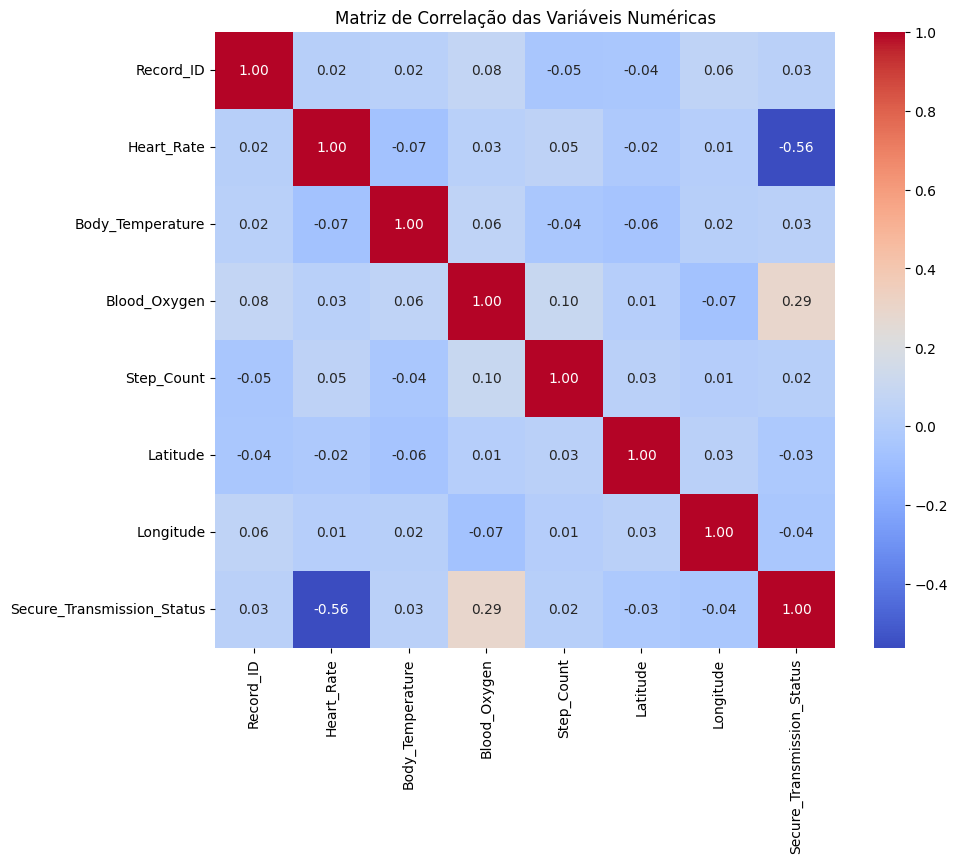

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [10]:
missing_values = df.isnull().sum()
display(missing_values)

,0
Record_ID,0
Athlete_ID,0
Timestamp,0
Heart_Rate,0
Body_Temperature,0
Blood_Pressure,0
Blood_Oxygen,0
Step_Count,0
Activity_Status,0
Latitude,0


In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Activity_Status', 'Record_ID'])
y = df['Activity_Status']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X['Timestamp'] = pd.to_datetime(X['Timestamp'])
X['Timestamp'] = X['Timestamp'].apply(lambda x: x.timestamp())

categorical_cols = ['Athlete_ID', 'Blood_Pressure']
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

X_treino_processado = preprocessor.fit_transform(X_treino)
X_teste_processado = preprocessor.transform(X_teste)

print("Dados preprocessados.")
print(f"Terino X: {X_treino_processado.shape}")
print(f"Teste X: {X_teste_processado.shape}")
print(f"Treino y: {y_treino.shape}")
print(f"Teste y: {y_teste.shape}")

Dados preprocessados.
Terino X: (400, 307)
Teste X: (100, 307)
Treino y: (400,)
Teste y: (100,)


In [17]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', random_state=42)

mlp.fit(X_treino_processado, y_treino)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

In [18]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_teste_processado)
accuracy = accuracy_score(y_teste, y_pred)
print(f"Acuracia: {accuracy:.4f}")

Acuracia: 0.2100
